## Satellite Image Classifier

**Author:** Jameson Gormley  
**Dataset:** EuroSAT Satellite Imagery Dataset  
**Data Source:** https://www.kaggle.com/datasets/apollo2506/eurosat-dataset  
**Date Started:** 23 June 2026  
**Status:** Complete

## Project Overview

The following project develops a Convolutional Neural Network (CNN) from scratch using PyTorch to classify satellite images into multiple land-use categories contained within the EuroSAT dataset. The objective is to investigate the end-to-end machine learning workflow, including:

- Image preprocessing and transformations with torchvision
- CNN architecture design and implementation with PyTorch
- Model training and validation
- Performance analysis and hyperparameter tuning
- Evaluation on previously unseen test data

## Useful Resources

CNN Theory & Implementation
- Building a CNN Blog: https://medium.com/@foxmike/cnn-for-image-classification-4d655c26b487  
- CNN Visualisation: https://youtu.be/pj9-rr1wDhM?si=O2RjuZTOtdtilI0M
- PyTorch Documentation: https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html  

In [ ]:
import kagglehub

path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

In [2]:
# formatting the source data into train, test, validation
import splitfolders

input_folder = 'dataset'
output_folder = 'split_dataset'

splitfolders.ratio(
    input_folder, 
    output=output_folder, 
    seed=1337, 
    ratio=(0.8, 0.1, 0.1), 
    group_prefix=None
)

In [3]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# creating a transformation pipeline for the input data that resizes images, formats them as an n dimensional array, and then normalises the values
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

train_data = datasets.ImageFolder("split_dataset/train", transform=transform)
val_data   = datasets.ImageFolder("split_dataset/val", transform=transform)
test_data  = datasets.ImageFolder("split_dataset/test", transform=transform)

In [4]:
train_loader = DataLoader(train_data, batch_size=6, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=6, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=6, shuffle=False)

In [6]:
# implementing the architecture of the CNN module using PyTorch modules
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # class torch.nn.Conv2d(in_channels, out_channels, kernel_size)
        # class torch.nn.MaxPool2d(kernel_size)
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool = nn.MaxPool2d(2)
        # class torch.nn.Linear(in_features, out_features)
        self.fc1 = nn.Linear(13 * 13 * 16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # output dimensions = input dimensions - kernel size + 1 
        
        # input to conv1 is [6,3, 64, 64], output is [6, 6, 60, 60] further halved by pooling [6, 6, 30, 30]
        x = self.pool(F.relu(self.conv1(x)))

        # input to conv2 is [6, 6, 30, 30], output is [6, 16 (output channels), 26, 26] further halved by pooling [6, 16, 13, 13]
        x = self.pool(F.relu(self.conv2(x)))

        # transforms input into a n x 1 vector
        # hence 13 x 13 x 16 output channels
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # output dimensions of linear transformation 3 must match the number of classes as these are the logits used in cross entropy loss calculation
        x = self.fc3(x)
        return x

net = Net()

## Baseline Model

In [17]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = net.to(device)

import torch.optim as optim

# loss will be measured using Cross Entropy function, which in PyTorch first applies a softmax activation function to the ouputs of the network
# each giving them a probability of the image belonging to that class
# cross entropy is then calculated which takes the sum of negative log of each probability for all classes
criterion = nn.CrossEntropyLoss()
optimiser = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

for epoch in range(10):

    model.train()
    running_loss = 0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        # clear the gradients from previous epoch
        optimiser.zero_grad()

        # complete the forward pass
        output = model(inputs)

        # forward loss computation
        loss = criterion(output, labels)

        # take a stochastic batch of data points and uses their gradient wrt loss to optimise incrementally (stochastic gradient descent)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    model.eval()

    val_loss = 0

    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
        
    print("Epoch:", epoch+1,
          "Train Loss:", running_loss/len(train_loader),
          "Val Loss:", val_loss/len(val_loader))

print("Finished training")

Epoch: 1 Train Loss: 1.5533054976330862 Val Loss: 1.1196384968194697
Epoch: 2 Train Loss: 1.0051610614504252 Val Loss: 1.0544606347402765
Epoch: 3 Train Loss: 0.8266591963441008 Val Loss: 0.9739620716878885
Epoch: 4 Train Loss: 0.6762368762169758 Val Loss: 0.7163205103177784
Epoch: 5 Train Loss: 0.5632412088878401 Val Loss: 0.7495674415644155
Epoch: 6 Train Loss: 0.4984564710468597 Val Loss: 0.7021032786682998
Epoch: 7 Train Loss: 0.3965139836429282 Val Loss: 0.6971405428264673
Epoch: 8 Train Loss: 0.3323961207122516 Val Loss: 0.7700448192268636
Epoch: 9 Train Loss: 0.2887818568268752 Val Loss: 0.8223244633449472
Epoch: 10 Train Loss: 0.2375816573593329 Val Loss: 0.8307770075101022
Finished training


## Analysis

In the intial training phase the model shows a consistent decrease in training loss across the epochs indicating that it is successfully learning patterns within the training dataset. However, validation loss decreases at a slower rate and shows instability across epochs, suggesting that the model's ability to generalise to unseen data is weaker than its performance on the training set. This indicates potential signs of overfitting or limited generalisation capacity in the baseline CNN architecture. Hence, further experimentation will be conducted to improve the model's generalisation ability on unseen validation data. 

## Experiment 1: Adding Dropout Regularisation

The baseline CNN is likely beginning to overfit the training data, as indicated by a faster decrease in training loss compared to validation loss, hence adding dropout should reduce overfitting by randomly deactivating neurons during training, forcing the model to learn more robust features and improving validation performance.

The dropout configuration is adopted from the reference architecture: https://medium.com/@vishnuam/dropout-in-convolutional-neural-networks-cnn-422a4a17da41

In [7]:
class NetDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(13 * 13 * 16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        # adding dropout with a 0.25 probability
        self.conv_dropout = nn.Dropout2d(p=0.25)
        self.fn_dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        # applying dropout rate of 0.25 following first convolutional later
        x = self.conv_dropout(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        # applying dropout rate of 0.5 following the first fully connected layer
        x = self.fn_dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net_dropout = NetDropout()

In [21]:
model = net_dropout.to(device)
# criterion does not change in any way from previous assignment of variable nn.CrossEntropyLoss()
optimiser = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# will let model train for more epochs as dropout reduces convergence speed
for epoch in range(15):

    model.train()
    running_loss = 0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
    
        optimiser.zero_grad()
        
        output = model(inputs)
        
        loss = criterion(output, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    model.eval()

    val_loss = 0

    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
        
    print("Epoch:", epoch+1,
          "Train Loss:", running_loss/len(train_loader),
          "Val Loss:", val_loss/len(val_loader))

print("Finished training")

Epoch: 1 Train Loss: 0.8408538795963654 Val Loss: 0.8313883701070315
Epoch: 2 Train Loss: 0.829527904618428 Val Loss: 0.8309416021634307
Epoch: 3 Train Loss: 0.8188545894550366 Val Loss: 0.8486848216731515
Epoch: 4 Train Loss: 0.7810085232007421 Val Loss: 0.9028328988918414
Epoch: 5 Train Loss: 0.7494095534275079 Val Loss: 0.8034453244538357
Epoch: 6 Train Loss: 0.7510608436477682 Val Loss: 0.8672424536529515
Epoch: 7 Train Loss: 0.7274844409380522 Val Loss: 0.9719461451501896
Epoch: 8 Train Loss: 0.7319703913555067 Val Loss: 0.9923741081915796
Epoch: 9 Train Loss: 0.7146242383233685 Val Loss: 0.8817731236459481
Epoch: 10 Train Loss: 0.6900609704730515 Val Loss: 0.8974052429983082
Epoch: 11 Train Loss: 0.6808999789076754 Val Loss: 0.9331360543384735
Epoch: 12 Train Loss: 0.6815462121344171 Val Loss: 0.953155243953483
Epoch: 13 Train Loss: 0.6494228764900213 Val Loss: 0.9151335325402518
Epoch: 14 Train Loss: 0.6760823414544574 Val Loss: 0.9025284560146327
Epoch: 15 Train Loss: 0.6471522

## Analysis

The model shows a steady decrease in training loss, however the validation loss remains noisy and does not demonstrate a downward trend across epochs. Compared to the baseline model, the introduction of dropout slows training convergence and reduces overfitting, but does not improve validation performance. This suggests that the current level of regularisation may be too strong relative to the model’s capacity, limiting its ability to learn more generalisable representations effectively. As a result, the dropout configuration should be adjusted to find a better balance between underfitting and overfitting.

## Experiment 2: Adjusting Regularisation

In [8]:
class NetDropout2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(13 * 13 * 16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        # applying dropout rate of 0.3 following the first fully connected layer and removing the convolutional layer dropout
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net2_dropout = NetDropout2()

In [26]:
model = net2_dropout.to(device)
# criterion does not change in any way from previous assignment of variable nn.CrossEntropyLoss()
optimiser = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# will let model train for more epochs as dropout reduces convergence speed
for epoch in range(15):

    model.train()
    running_loss = 0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
    
        optimiser.zero_grad()
        
        output = model(inputs)
        
        loss = criterion(output, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    model.eval()

    val_loss = 0

    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
        
    print("Epoch:", epoch+1,
          "Train Loss:", running_loss/len(train_loader),
          "Val Loss:", val_loss/len(val_loader))

print("Finished training")

Epoch: 1 Train Loss: 1.6281708059708278 Val Loss: 1.316606320929196
Epoch: 2 Train Loss: 1.1484750667193697 Val Loss: 0.9778539310375022
Epoch: 3 Train Loss: 0.9389876822713349 Val Loss: 0.8090784248875247
Epoch: 4 Train Loss: 0.8047504638968449 Val Loss: 0.7919525415496901
Epoch: 5 Train Loss: 0.7519791319402349 Val Loss: 0.6830462026264933
Epoch: 6 Train Loss: 0.6710095541841454 Val Loss: 0.7707416377304536
Epoch: 7 Train Loss: 0.5928488767557751 Val Loss: 0.7521886233025644
Epoch: 8 Train Loss: 0.5520180812423738 Val Loss: 0.6964417831068234
Epoch: 9 Train Loss: 0.5040314600946779 Val Loss: 0.6535451854592086
Epoch: 10 Train Loss: 0.5003812971314539 Val Loss: 0.6532963438871472
Epoch: 11 Train Loss: 0.4242335399457887 Val Loss: 0.6987311410587346
Epoch: 12 Train Loss: 0.3905977789084298 Val Loss: 0.705857284144804
Epoch: 13 Train Loss: 0.3677553748421754 Val Loss: 0.7473558719973354
Epoch: 14 Train Loss: 0.34857429894034997 Val Loss: 0.7090355202024027
Epoch: 15 Train Loss: 0.309466

## Analysis

In this experiment, the regularisation strength was reduced by removing dropout from the first convolutional layer and decreasing the dropout probability applied after the first fully connected layer from 0.5 to 0.3. The updated architecture demonstrates the most balanced training of the three models. Training loss decreases consistently throughout all 15 epochs, indicating that the model is successfully learning meaningful features from the training dataset. More importantly, the validation loss reaches its lowest value of approximately 0.65 during epochs 9 and 10, representing the strongest validation performance observed across all experiments conducted thus far. Compared to the baseline model, the introduction of moderate dropout appears to delay the onset of overfitting while still allowing the network to learn effectively.

In contrast, the previous dropout configuration applied excessive regularisation, resulting in slower convergence and poorer validation performance. Following epoch 10, validation loss begins to increase while training loss continues to decrease. This instability indicates that the model has begiun to overfitting to the training data, reducing its ability to generalise to unseen samples. Overall, reducing the dropout strength produced the best trade off between model learning capacity and generalisation performance, making this architecture the strongest candidate for final evaluation on the test dataset.

## Final Model Selection

Three CNN architectures were developed and iteratively refined through controlled experiments to improve generalisation performance. Each model will be trained independently, with checkpointing implemented to retain the model state achieving the lowest validation loss, as this metric provides the best estimate of performance on unseen data. Validation loss is used as the primary selection criterion because it reflects the model’s ability to generalise beyond the training set and is less susceptible to overfitting compared to training loss. For each architecture, training and validation loss curves will be plotted across epochs to analyse convergence behaviour, stability, and overfitting tendencies. These results will be used to compare model performance and justify final model selection prior to evaluation on the test set.

In [14]:
# probably would have been wiser to develop a training function a little earlier for the sake of redundancy, but oh well this is an incremental
# and transparent documentation of the building testing validating process
def train_model(device, model, save_path, criterion, optimiser, train_loader, val_loader, epochs):

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_epoch = None

    for epoch in range(epochs):

        running_loss = 0
        model.train()
        
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
        
            optimiser.zero_grad()
            output = model(inputs)
            loss = criterion(output, labels)
            loss.backward()
            optimiser.step()
            
            running_loss += loss.item()
    
        model.eval()

        running_val_loss = 0
    
        with torch.no_grad():
            for data in val_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
    
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        running_loss = running_loss/len(train_loader)
        train_losses.append(running_loss) 

        running_val_loss = running_val_loss/len(val_loader)
        val_losses.append(running_val_loss) 

        if running_val_loss < best_val_loss:
            best_val_loss = running_val_loss
            best_epoch = epoch + 1
            
            torch.save(model.state_dict(), save_path)

    return best_epoch, best_val_loss, train_losses, val_losses

In [15]:
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model_base = Net().to(device)
model_dropout1 = NetDropout().to(device)
model_dropout2 = NetDropout2().to(device)

criterion = nn.CrossEntropyLoss()

optim_base = optim.SGD(model_base.parameters(), lr=0.001, momentum=0.9)
optim_d1 = optim.SGD(model_dropout1.parameters(), lr=0.001, momentum=0.9)
optim_d2 = optim.SGD(model_dropout2.parameters(), lr=0.001, momentum=0.9)

epochs = 15

results = {}

results["baseline"] = train_model(
    device,
    model_base,
    "best_baseline.pth",
    criterion,
    optim_base,
    train_loader,
    val_loader,
    epochs
)

results["dropout1"] = train_model(
    device,
    model_dropout1,
    "best_dropout1.pth",
    criterion,
    optim_d1,
    train_loader,
    val_loader,
    epochs
)

results["dropout2"] = train_model(
    device,
    model_dropout2,
    "best_dropout2.pth",
    criterion,
    optim_d2,
    train_loader,
    val_loader,
    epochs
)

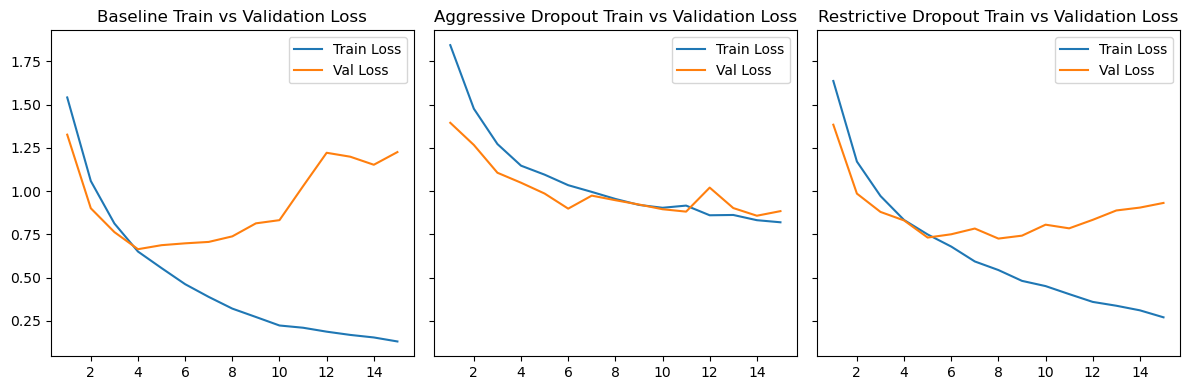

In [76]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

x = range(1, len(results["baseline"][3]) + 1)

# baseline model 
y1 = results["baseline"][2]
y2 = results["baseline"][3]

ax1.plot(x, y1, label="Train Loss")
ax1.plot(x, y2, label="Val Loss")
ax1.set_title('Baseline Train vs Validation Loss')
ax1.legend()

# experiment 1 aggressive dropout
y1 = results["dropout1"][2]
y2 = results["dropout1"][3]

ax2.plot(x, y1, label="Train Loss")
ax2.plot(x, y2, label="Val Loss")
ax2.set_title('Aggressive Dropout Train vs Validation Loss')
ax2.legend()

# experiment 2 restrictive dropout
y1 = results["dropout2"][2]
y2 = results["dropout2"][3]

ax3.plot(x, y1, label="Train Loss")
ax3.plot(x, y2, label="Val Loss")
ax3.set_title('Restrictive Dropout Train vs Validation Loss')
ax3.legend()

plt.tight_layout()
plt.show()

## Analysis

Aggressive dropout results in significantly reduced performance, with both training and validation accuracy plateauing early. This suggests that excessive regularisation has limited the model’s capacity to learn meaningful feature representations, leading to underfitting. The baseline model achieves strong performance, reaching its highest validation accuracy early in training before performance degrades as training continues. This pattern is indicative of overfitting, where continued optimisation on the training set reduces generalisation performance on unseen data. 

The more moderate dropout configuration produces results comparable to the baseline model, showing slightly improved stability in training dynamics but no substantial improvement in final validation accuracy. This suggests that while regularisation can help control overfitting, the baseline architecture already provides a strong balance between capacity and generalisation for this dataset. Some variation between runs may also be attributed to stochastic elements in training, including random weight initialisation and data shuffling as no fixed seed was used.

In [49]:
## Test Accuracy
def evaluate(model, test_loader):
    model.eval()
    
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    accuracy = correct / total
    return accuracy

In [67]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model_base.load_state_dict(torch.load("best_baseline.pth", map_location=device))
model_dropout1.load_state_dict(torch.load("best_dropout1.pth", map_location=device))
model_dropout2.load_state_dict(torch.load("best_dropout2.pth", map_location=device))

test_loader = DataLoader(test_data, batch_size=6, shuffle=False)

In [68]:
model = model_base
print(evaluate(model, test_loader))

0.7688888888888888


In [69]:
model = model_dropout1
print(evaluate(model, test_loader))

0.6781481481481482


In [70]:
model = model_dropout2
print(evaluate(model, test_loader))

0.7677777777777778


In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def DisplayConfusionMatrix(model, class_names, test_loader):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_predictions, normalize= 'true')
    cm = np.round(cm, 2)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.show()

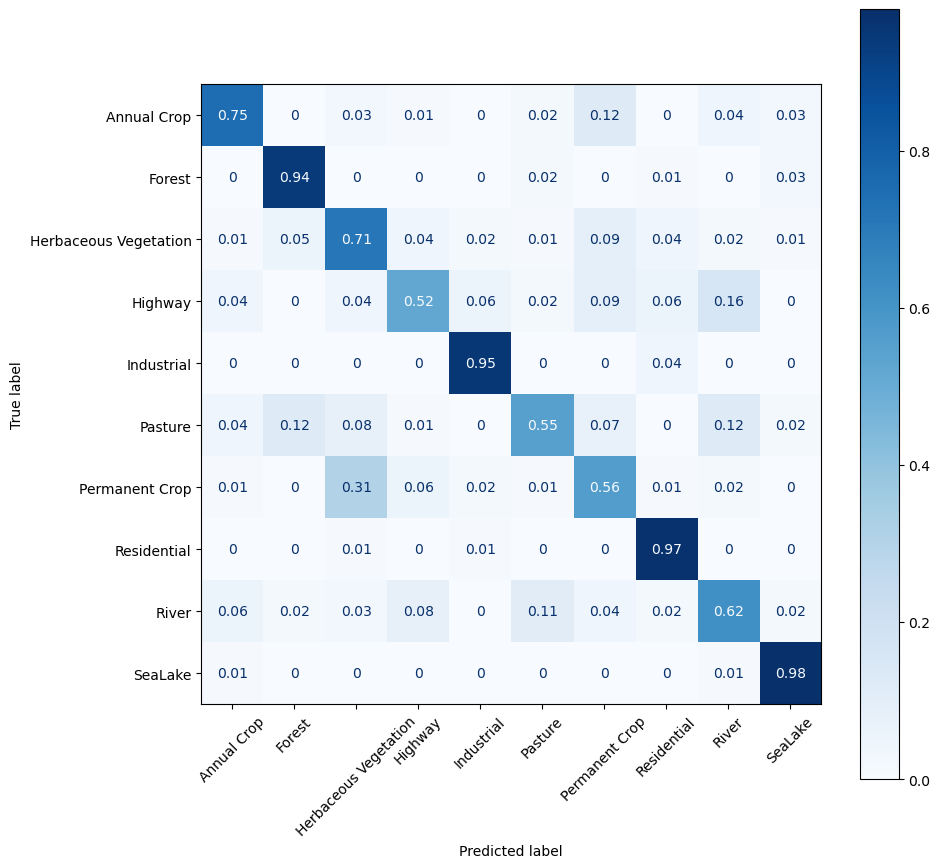

In [124]:
class_names = [
    "Annual Crop",
    "Forest",
    "Herbaceous Vegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "Permanent Crop",
    "Residential",
    "River",
    "Sea Lake"
]

model_dropout2.load_state_dict(torch.load("best_dropout2.pth", map_location=device))
model = model_dropout2

test_loader = DataLoader(test_data, batch_size=6, shuffle=False)

DisplayConfusionMatrix(model, class_names, test_loader)

## Analysis 

The confusion matrix displays row normalised classification performance, where each row represents the true class and values indicate the proportion of predictions assigned to each predicted class. This evaluation is performed on the test set using the Experiment 2 model, selected due to its strong balance between validation performance and training stability. The model demonstrates strong classification performance for classes such as Sea/Lake, Residential, Industrial, and Forest, achieving over 94% correct classification in these categories. These classes are visually distinctive in satellite imagery, which likely contributes to their high separability in feature space. 

However, the model shows reduced performance on more visually similar classes such as Highways, Pastures, and Cropland-related categories. In particular, Crops are frequently misclassified as Herbaceous Vegetation, with approximately 31% of crop samples predicted as this class. This is likely due to overlapping visual features such as texture, colour distribution, and vegetation density, which are difficult to distinguish using a relatively shallow CNN architecture. Overall, the results suggest that while the model performs well on structurally distinct classes, its limitations become apparent in fine grained vegetation based classification tasks where inter-class similarity is high.

## Predicition Visualisation

In [166]:
import random

def prediction_visualisation(model, test_dataset, class_names):
    # set model to evaluation mode so it is not training 
    model.eval()
    
    # choose a random picture from the test data
    index = random.randint(0, len(test_dataset) - 1)

    image, true_class = test_dataset[index]

    # transform image to the correct tensor for the model
    image_tensor = image.unsqueeze(0).to(device)

    # apply softmax to the logits (outputs) of the model and map the result to the label
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        prediction = torch.argmax(probabilities, dim=1).item()

    image = np.clip(image, 0, 1)
    
    return image, true_class, prediction, probabilities[0][prediction].item()

In [167]:
class_names = [
    "Annual Crop",
    "Forest",
    "Herbaceous Vegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "Permanent Crop",
    "Residential",
    "River",
    "Sea Lake"
]

model_dropout2.load_state_dict(torch.load("best_dropout2.pth", map_location=device))
model = model_dropout2

test_dataset = test_loader.dataset

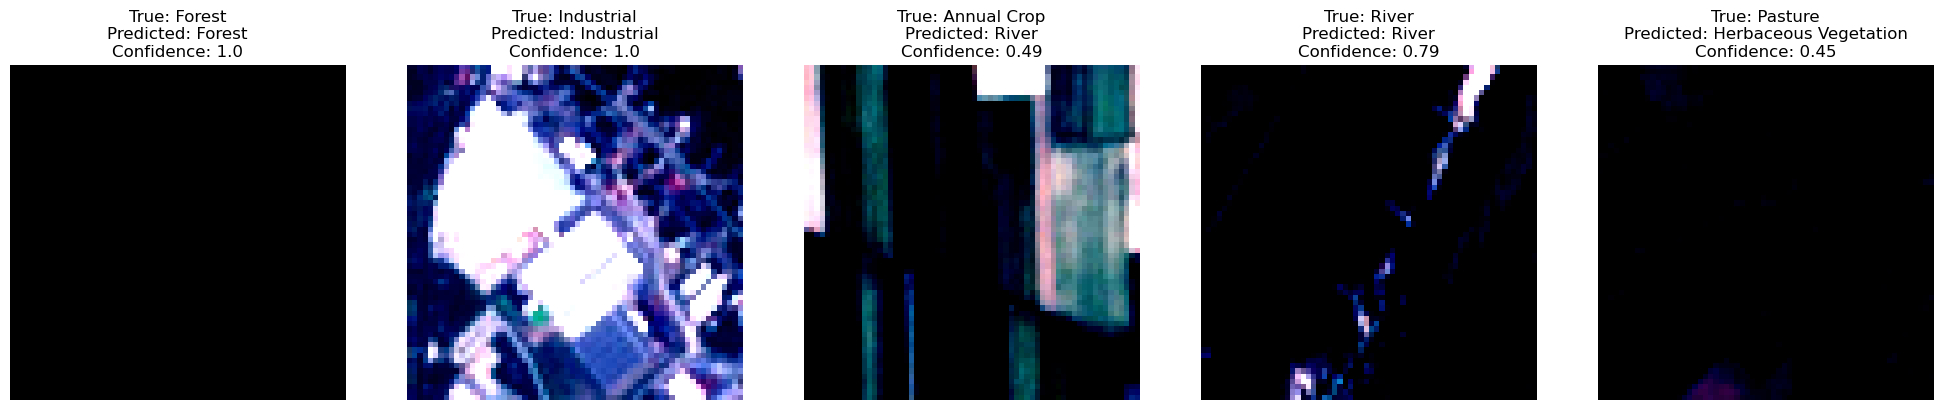

In [168]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image, label, predicted, confidence = prediction_visualisation(model, test_dataset, class_names)

    img = image.permute(1, 2, 0).cpu().numpy()

    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {class_names[label]}\n"
        f"Predicted: {class_names[predicted]}\n"
        f"Confidence: {np.round(confidence, 2)}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Conclusion 

This project developed and evaluated multiple Convolutional Neural Network architectures for image classification using the EuroSAT satellite imagery dataset. Incremental modifications were made to the baseline architecture in order to address observed weaknesses such as training instability and overfitting, with the goal of improving generalisation performance.

The results demonstrated that all models were able to learn meaningful patterns in the feature space and achieve reasonable generalisation performance, however differences emerged as a result of varying regularisation strategies. The baseline model showed rapid convergence during training but showed signs of early overfitting after only a few epochs. The second model applied dropout to both the first convolutional and first fully connected layers which proved overly restrictive, resulting in slower learning and reduced overall performance. The most balanced performance was achieved by the final model, which applied dropout only to the first fully connected layer.

Further evaluation on the test set showed that both the baseline and final dropout model achieved approximately 76–77% accuracy, while the more aggressively regularised model achieved lower performance at around 68%. A confusion matrix was created from final dropout model, which highlighted strong classification performance for distinct land types such as Sea and Residential. However, the model struggled with classes that share similar visual characteristics particularly for vegetation based categories such as Crops and Herbaceous Vegetation.

Overall, this project demonstrates a typica machine learning workflow, including data preprocessing, model design, training, validation, and evaluation. It provided practical experience with key deep learning concepts such as regularisation, overfitting, and model selection, and reinforced an understanding of the trade offs involved in designing convolutional neural networks for classification tasks.